In [1]:
import numpy as np
import pandas as pd

C:\Users\ankit\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
df = pd.read_csv("placement.csv")

In [3]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [4]:
# Steps
 #  0. Preprocess = EDA + feature Selection
 #  1. Extract input and output cols
 #  2. Scale the vaalues
 #  3. Train test Split
 #  4. Train the model
 #  5. Evaluate the model/model selection
 #  6. Deploy the model

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [6]:
df = df.iloc[:,1:]

In [7]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


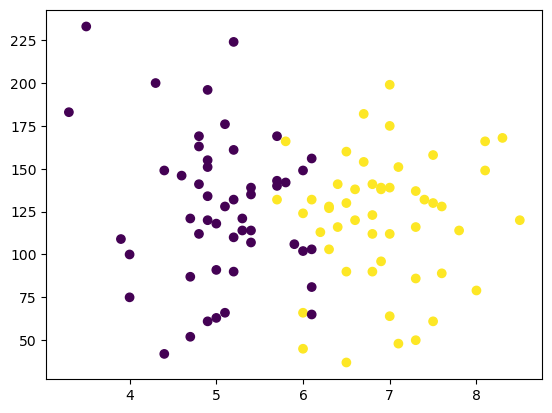

In [8]:
import matplotlib.pyplot as plt

plt.scatter(df['cgpa'],df['iq'], c= df['placement'])

In [9]:
# my work is to buikld a ml which can understand the pattern in this data
X = df.iloc[:,0:2]
y = df.iloc[:, -1]

In [10]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [11]:
y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.1)

In [13]:
X_train

,cgpa,iq
79,6.5,90.0
74,6.7,154.0
76,4.9,155.0
39,4.6,146.0
67,5.0,118.0
...,...,...
52,7.0,175.0
42,7.6,89.0
24,4.7,121.0
60,6.9,139.0


In [14]:
y_train

79    1
74    1
76    0
39    0
67    0
     ..
52    1
42    1
24    0
60    1
80    0
Name: placement, Length: 90, dtype: int64

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

In [16]:
X_train

array([[ 0.41885391, -0.9206894 ],
       [ 0.59836273,  0.74907475],
       [-1.01721663,  0.77516482],
       [-1.28647986,  0.54035423],
       [-0.92746223, -0.19016758],
       [ 1.58566122, -0.29452784],
       [ 1.22664359,  0.17509332],
       [ 0.41885391,  0.90561514],
       [ 1.13688918, -0.24234771],
       [ 0.05983627, -1.15549999],
       [ 0.59836273,  1.47959657],
       [ 0.41885391, -2.30346284],
       [ 0.23934509,  0.044643  ],
       [ 0.95738036,  0.67080456],
       [-0.658199  , -0.11189739],
       [ 0.41885391,  0.12291319],
       [-0.658199  , -0.29452784],
       [-1.10697104, -0.34670797],
       [ 0.68811714, -0.05971726],
       [-0.74795341,  2.5753793 ],
       [ 1.316398  ,  0.12291319],
       [-0.20942695,  0.43599397],
       [-0.83770782,  1.32305618],
       [-1.46598868,  0.61862443],
       [ 0.68811714,  0.40990391],
       [-1.01721663,  0.22727345],
       [ 1.13688918, -1.964292  ],
       [ 0.05983627,  0.80125488],
       [-1.82500631,

In [17]:
X_test = scaler.transform(X_test)

In [18]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()

In [19]:
# model_training
clf.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [20]:
y_pred = clf.predict(X_test)

In [21]:
y_test

94    0
17    0
98    1
84    0
96    0
36    0
45    1
93    1
37    1
9     0
Name: placement, dtype: int64

In [22]:
y_pred

array([0, 0, 1, 0, 0, 0, 0, 1, 1, 0])

In [23]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.9

In [28]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

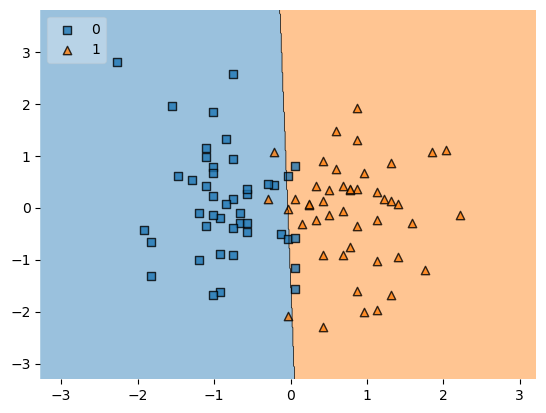

In [29]:
plot_decision_regions(X_train,y_train.values, clf=clf, legend =2)